# ARIMA Modelling in R

## Overview

ARIMA(p,d,q) combines three components:

| Parameter | Meaning |
|---|---|
| **p** — AR order | Current value depends on p past values |
| **d** — differencing | Differences applied to achieve stationarity |
| **q** — MA order | Current value depends on q past forecast errors |

**Workflow:**
1. Visualise — look for trend, variance changes, outliers
2. Stationarity — test with ADF/KPSS, difference if needed (→ d)
3. ACF/PACF — identify candidate p and q
4. Fit candidates — compare by AICc
5. Diagnose residuals — Ljung-Box, residual ACF, normality
6. Forecast — with prediction intervals; evaluate on test set

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(forecast)   # auto.arima(), Arima(), checkresiduals(), accuracy()
library(tseries)    # adf.test()
library(patchwork)

set.seed(42)

# Simulate: ARMA(1,1) with drift
n <- 150
eco_series <- ts(
  30 + 0.1 * seq_len(n) +
  arima.sim(list(ar=0.65, ma=0.3), n=n, sd=4),
  start=c(2010,1), frequency=1
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'forecast' was built under R version 4.4.3"
Registered S3 method overwritten by 'quantmod':
  method       

---

## Steps 1–3: Identification

Warning message in tseries::adf.test(eco_series):
"p-value smaller than printed p-value"


ADF p = 0.0100
ndiffs (KPSS): 1


Warning message in tseries::adf.test(eco_diff):
"p-value smaller than printed p-value"


After diff: ADF p = 0.0100


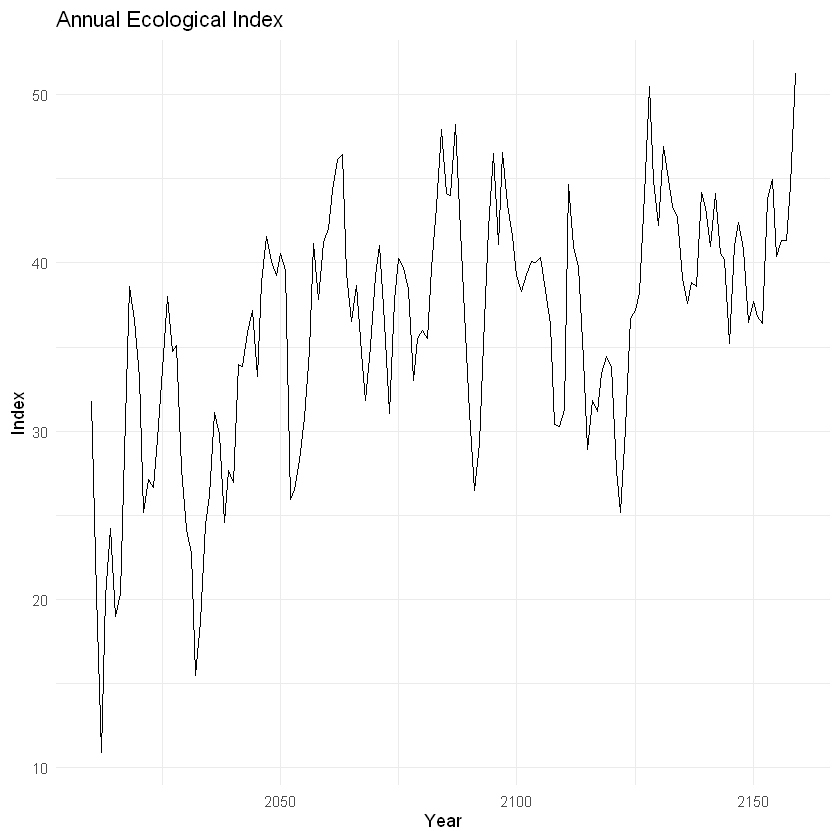

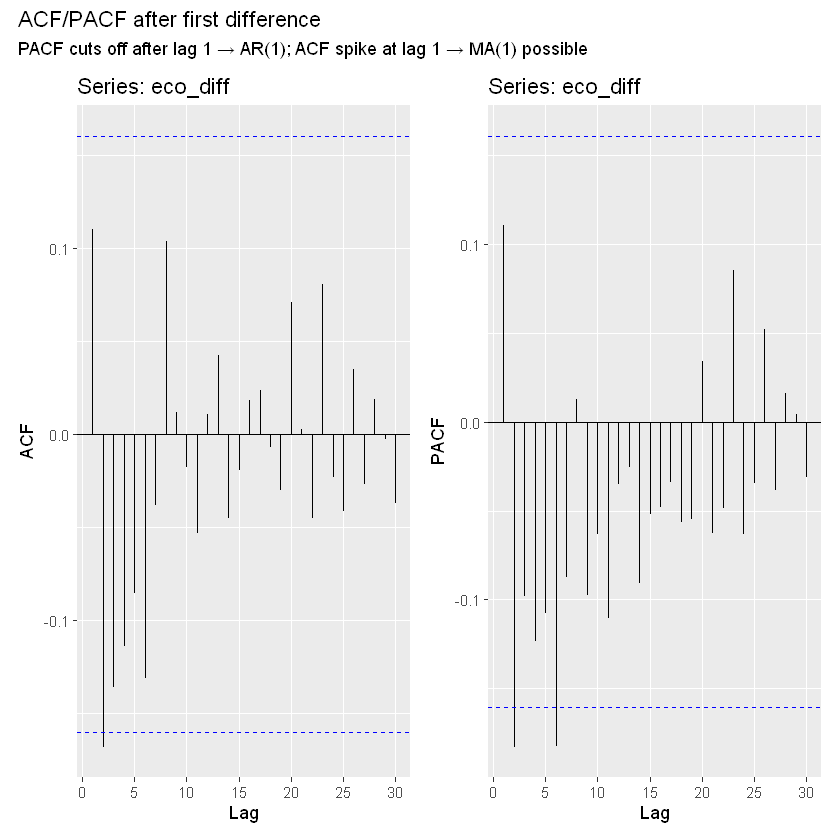

In [2]:
autoplot(eco_series) +
  labs(title="Annual Ecological Index", x="Year", y="Index") +
  theme_minimal()

# Stationarity
cat(sprintf("ADF p = %.4f\n", tseries::adf.test(eco_series)$p.value))
cat(sprintf("ndiffs (KPSS): %d\n", forecast::ndiffs(eco_series, test="kpss")))

eco_diff <- diff(eco_series)  # d = 1
cat(sprintf("After diff: ADF p = %.4f\n", tseries::adf.test(eco_diff)$p.value))

# ACF/PACF of differenced series
(forecast::ggAcf(eco_diff, lag.max=30) | forecast::ggPacf(eco_diff, lag.max=30)) +
  patchwork::plot_annotation(
    title="ACF/PACF after first difference",
    subtitle="PACF cuts off after lag 1 → AR(1); ACF spike at lag 1 → MA(1) possible"
  )

---

## Step 4: Fitting and Model Comparison

In [3]:
# Manual candidates
candidates <- list(
  "ARIMA(1,1,0)" = forecast::Arima(eco_series, order=c(1,1,0)),
  "ARIMA(0,1,1)" = forecast::Arima(eco_series, order=c(0,1,1)),
  "ARIMA(1,1,1)" = forecast::Arima(eco_series, order=c(1,1,1)),
  "ARIMA(2,1,1)" = forecast::Arima(eco_series, order=c(2,1,1))
)

map_dfr(names(candidates), function(nm) {
  m <- candidates[[nm]]
  tibble(model=nm, AICc=m$aicc, BIC=BIC(m))
}) %>%
  mutate(delta_AICc=round(AICc - min(AICc), 2)) %>%
  arrange(AICc) %>% print()

# Auto selection — full grid search
auto_fit <- forecast::auto.arima(
  eco_series,
  seasonal      = FALSE,
  stepwise      = FALSE,   # exhaustive search
  approximation = FALSE,   # exact likelihood
  ic            = "aicc"
)
cat("\nauto.arima selected: "); print(auto_fit)

# A tibble: 4 × 4
  model         AICc   BIC delta_AICc
  <chr>        <dbl> <dbl>      <dbl>
1 ARIMA(2,1,1)  845.  857.        0  
2 ARIMA(0,1,1)  861.  867.       15.9
3 ARIMA(1,1,1)  862.  871.       16.8
4 ARIMA(1,1,0)  862.  868.       16.9

auto.arima selected: Series: eco_series 
ARIMA(2,1,1) 

Coefficients:
         ar1      ar2      ma1
      0.9377  -0.2866  -0.9268
s.e.  0.0865   0.0827   0.0384

sigma^2 = 16.34:  log likelihood = -418.49
AIC=844.98   AICc=845.26   BIC=856.99


---

## Step 5: Residual Diagnostics


	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)
Q* = 3.6766, df = 7, p-value = 0.8162

Model df: 3.   Total lags used: 10

Ljung-Box Q(20)=6.919, p=0.9846

Training accuracy:
                    ME    RMSE      MAE        MPE     MAPE      MASE
Training set 0.4604634 3.98773 3.146233 -0.1032667 9.661225 0.9169078
                    ACF1
Training set -0.02078959


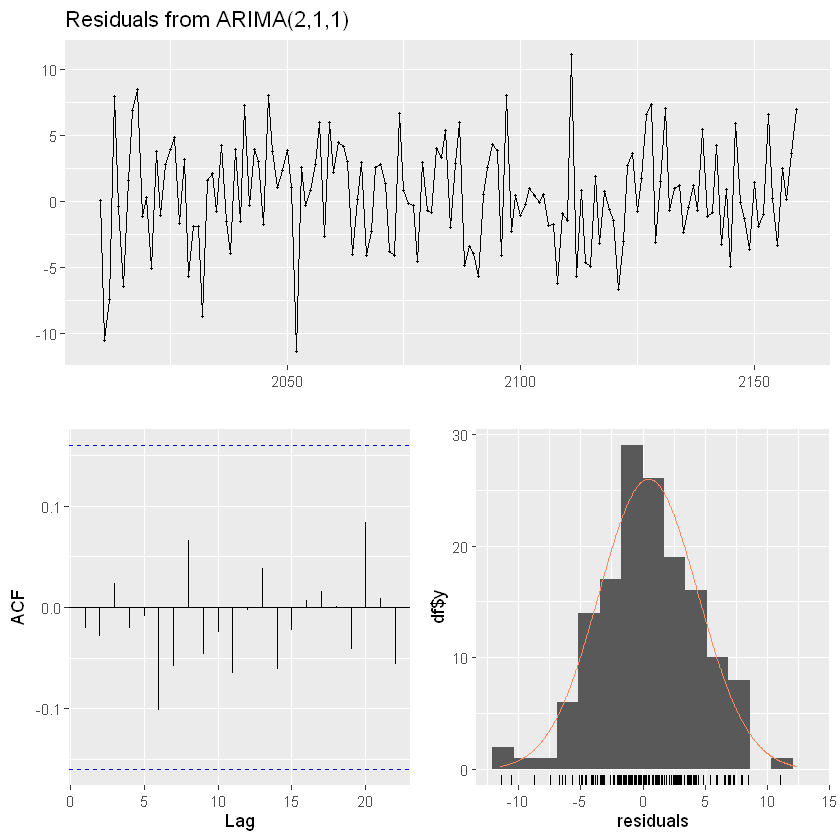

In [4]:
# checkresiduals: time plot + ACF + histogram + Ljung-Box
forecast::checkresiduals(auto_fit)

lb <- Box.test(residuals(auto_fit), lag=20, type="Ljung-Box",
               fitdf=sum(auto_fit$arma[1:2]))
cat(sprintf("Ljung-Box Q(%d)=%.3f, p=%.4f\n", 20, lb$statistic, lb$p.value))
# p > 0.05: residuals consistent with white noise → model adequate

cat("\nTraining accuracy:\n")
print(forecast::accuracy(auto_fit))

---

## Step 6: Forecasting and Test-Set Evaluation


Test-set accuracy:
                    ME     RMSE      MAE       MPE      MAPE     MASE
Training set 0.3852231 4.138169 3.322573 -0.433343 10.619531 0.913725
Test set     3.9740943 5.275571 4.280854  8.991170  9.845778 1.177257
                    ACF1 Theil's U
Training set -0.02778428        NA
Test set      0.37051172  1.513745


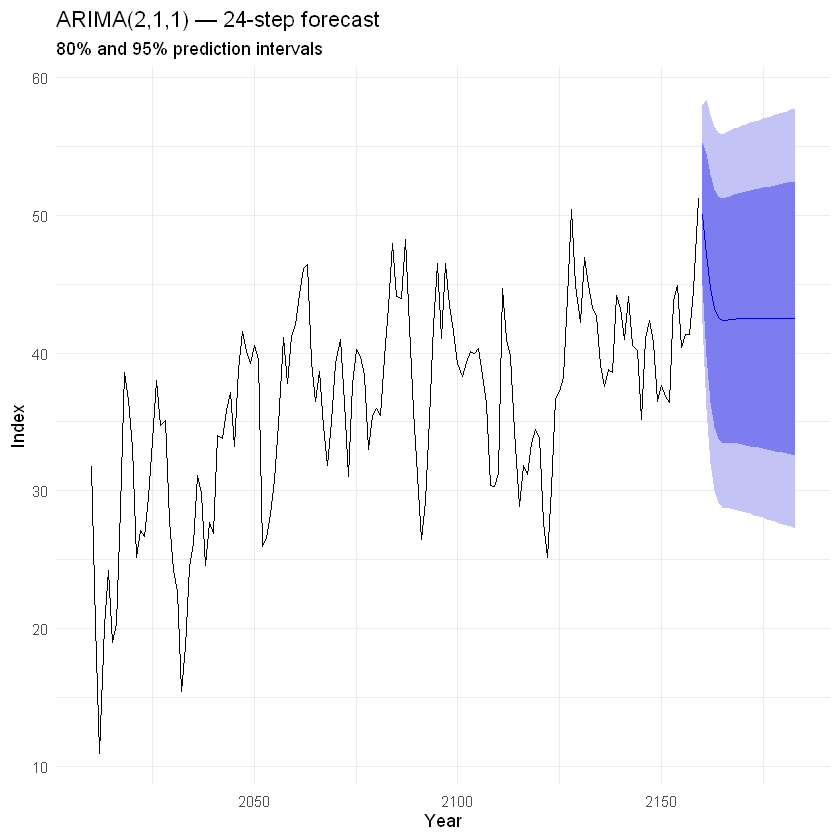

In [5]:
# Forecast 24 steps ahead
fc <- forecast::forecast(auto_fit, h=24, level=c(80,95))

autoplot(fc) +
  labs(title=sprintf("ARIMA(%d,%d,%d) — 24-step forecast",
                     auto_fit$arma[1], auto_fit$arma[6], auto_fit$arma[2]),
       subtitle="80% and 95% prediction intervals",
       x="Year", y="Index") +
  theme_minimal()

# ── Test-set evaluation ───────────────────────────────────────────────────────
train <- head(eco_series, 120)
test  <- tail(eco_series, 30)

fit_train <- forecast::auto.arima(train, seasonal=FALSE, stepwise=FALSE)
fc_test   <- forecast::forecast(fit_train, h=30)

cat("\nTest-set accuracy:\n")
print(forecast::accuracy(fc_test, test))
# Large train vs. test RMSE gap → overfitting
# MASE > 1 → worse than naive forecast (red flag)

---

## Reporting

In [6]:
# Extract coefficients
print(broom::tidy(auto_fit))

# Standard format:
# "An ARIMA(p,d,q) model was fitted using the forecast package
#  (Hyndman & Khandakar 2008); order selected by AICc via exhaustive
#  grid search (auto.arima, stepwise=FALSE). Residual diagnostics
#  confirmed adequate fit: Ljung-Box Q(20)=X.X, p=.XXX. Test-set
#  RMSE=X.XX (training RMSE=X.XX)."
cat("Reporting guidance above.\n")

# A tibble: 3 × 3
  term  estimate std.error
  <chr>    <dbl>     <dbl>
1 ar1      0.938    0.0865
2 ar2     -0.287    0.0827
3 ma1     -0.927    0.0384
Reporting guidance above.


---

## Common Pitfalls

**1. Skipping residual diagnostics**  
A model that passes AIC selection but has residual autocorrelation is misspecified. Always run `checkresiduals()` before reporting.

**2. Using `stepwise=TRUE`**  
The stepwise search can miss the global AICc optimum. Use `stepwise=FALSE` for publication — the extra compute time is worth it.

**3. Evaluating only on the training set**  
In-sample accuracy measures fit, not forecast quality. Always evaluate on a held-out test set using a chronological split — never random sampling.

**4. Over-differencing**  
Differencing more than necessary introduces MA unit roots. Let `ndiffs()` guide the choice of d; do not increase d because the undifferenced series looks non-normal.

**5. Treating prediction intervals as confidence intervals**  
ARIMA prediction intervals widen with forecast horizon and account for stochastic error, not parameter uncertainty. They are often too narrow for long horizons. Always communicate uncertainty visually.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*